## 1. Data Acquisition

In [11]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [12]:
files = sorted(glob.glob("all_batting/batting_part_*.csv"))
df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
print(df.shape)

/var/folders/7y/c8_smbxj3v13gsc7ld8064h80000gn/T/ipykernel_98519/2110351657.py:2: DtypeWarning: Columns (0: Unnamed: 39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)


(5746326, 89)


## 2. Data Cleaning

In [13]:
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
print(df[df['gid'].isnull()].shape)
print(df[df['gid'].isnull()].head())

(746327, 85)
         gid   id team  b_lp  b_seq stattype  b_pa  b_ab  b_r  b_h  ...  y.1  \
4999999  NaN  NaN  NaN   NaN    NaN      NaN   NaN   NaN  NaN  NaN  ...    y   
5000000  NaN  NaN  NaN   NaN    NaN      NaN   NaN   NaN  NaN  NaN  ...    y   
5000001  NaN  NaN  NaN   NaN    NaN      NaN   NaN   NaN  NaN  NaN  ...    y   
5000002  NaN  NaN  NaN   NaN    NaN      NaN   NaN   NaN  NaN  NaN  ...    y   
5000003  NaN  NaN  NaN   NaN    NaN      NaN   NaN   NaN  NaN  NaN  ...    y   

         ARI201208110  wheer001  ARI   9  20120811  PHO01    h  WAS  1.6  
4999999           NaN       NaN  NaN NaN       NaN    NaN  NaN  NaN  NaN  
5000000           NaN       NaN  NaN NaN       NaN    NaN  NaN  NaN  NaN  
5000001           NaN       NaN  NaN NaN       NaN    NaN  NaN  NaN  NaN  
5000002           NaN       NaN  NaN NaN       NaN    NaN  NaN  NaN  NaN  
5000003           NaN       NaN  NaN NaN       NaN    NaN  NaN  NaN  NaN  

[5 rows x 85 columns]


In [14]:
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
df = df.dropna(subset=['gid'])
print(df.shape)
print(df.isnull().sum()[df.isnull().sum() > 0])

(4999999, 85)
b_lp         405212
b_seq        402149
b_pa          47704
b_ab          15116
b_r           13863
             ...   
20120811    4999999
PHO01       4999999
h           4999999
WAS         4999999
1.6         4999999
Length: 73, dtype: int64


In [15]:
df = df[df['b_ab'] > 0]
print(df.shape)

(4024655, 85)


In [16]:
print(df.columns.tolist())
print(df.shape)

['gid', 'id', 'team', 'b_lp', 'b_seq', 'stattype', 'b_pa', 'b_ab', 'b_r', 'b_h', 'b_d', 'b_t', 'b_hr', 'b_rbi', 'b_sh', 'b_sf', 'b_hbp', 'b_w', 'b_iw', 'b_k', 'b_sb', 'b_cs', 'b_gdp', 'b_xi', 'b_roe', 'dh', 'ph', 'pr', 'date', 'number', 'site', 'vishome', 'opp', 'win', 'loss', 'tie', 'gametype', 'box', 'pbp', 'eject', 'BOS194108061', 'sturj101', 'NYA', '1', '1.1', 'value', '4', '3', '0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '1.2', '0.9', '0.10', '0.11', '0.12', '1.3', '0.13', '0.14', '19410806', '1.4', 'BOS07', 'v', 'BOS', '0.15', '1.5', '0.16', 'regular', 'y', 'y.1', 'ARI201208110', 'wheer001', 'ARI', '9', '20120811', 'PHO01', 'h', 'WAS', '1.6']
(4024655, 85)


In [17]:
good_cols = ['gid', 'id', 'team', 'b_lp', 'b_seq', 'stattype', 'b_pa', 'b_ab', 'b_r', 'b_h', 
             'b_d', 'b_t', 'b_hr', 'b_rbi', 'b_sh', 'b_sf', 'b_hbp', 'b_w', 'b_iw', 'b_k', 
             'b_sb', 'b_cs', 'b_gdp', 'b_xi', 'b_roe', 'dh', 'ph', 'pr', 'date', 'number', 
             'site', 'vishome', 'opp', 'win', 'loss', 'tie', 'gametype', 'box', 'pbp', 'eject']

df = df[good_cols]
print(df.shape)
print(df.isnull().sum()[df.isnull().sum() > 0])

(4024655, 40)
b_lp         3654
b_seq        3577
b_pa        30967
b_r          1789
b_h           443
b_d          5522
b_t          5850
b_hr         4661
b_rbi       46645
b_sh         9000
b_sf       238734
b_hbp       10499
b_w          8420
b_iw       224043
b_k        112862
b_sb         8673
b_cs       250036
b_gdp      254586
b_xi        46075
b_roe      281549
dh        3899543
ph        3664399
pr        4010200
number     171135
box          4082
pbp        268026
eject     4017244
dtype: int64


In [18]:
df = df.drop(columns=['eject', 'pr', 'ph', 'dh', 'box', 'pbp'])
stat_cols = ['b_pa', 'b_r', 'b_h', 'b_d', 'b_t', 'b_hr', 'b_rbi', 'b_sh', 
             'b_sf', 'b_hbp', 'b_w', 'b_iw', 'b_k', 'b_sb', 'b_cs', 
             'b_gdp', 'b_xi', 'b_roe', 'b_lp', 'b_seq']
df[stat_cols] = df[stat_cols].fillna(0)
df['number'] = df['number'].fillna(0)
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


In [19]:
print(df['date'].astype(str).str[:4].min())

1898


In [20]:
df['year'] = df['date'].astype(int).astype(str).str[:4].astype(int)
df_early = df[df['year'] <= 1950]
df_mid = df[(df['year'] >= 1951) & (df['year'] <= 1990)]
df_contemporary = df[df['year'] >= 1991]
print(df_early.shape)
print(df_mid.shape)
print(df_contemporary.shape)

(1233120, 35)
(1302156, 35)
(1489379, 35)


In [25]:
df1 = pd.read_csv("Project/mlb_teams.csv")
print(df_teams.shape)

(2784, 41)


In [28]:
df_teams = df1.dropna(subset=['team_name'])
df_teams = df1[df1['games_played'] > 0]
print(df_teams.shape)
print(df_teams.isnull().sum()[df_teams.isnull().sum() > 0])

(2784, 41)
division_id              1346
home_games                228
division_winner          1374
wild_card_winner         2010
league_winner              28
world_series_winner       248
strikeouts_by_batters      16
stolen_bases               76
caught_stealing           708
batters_hit_by_pitch     1066
sacrifice_flies          1370
home_attendance           108
dtype: int64


In [29]:
flag_cols = ['division_winner', 'wild_card_winner', 'league_winner', 'world_series_winner']
df_teams[flag_cols] = df_teams[flag_cols].fillna('N')
num_cols = ['home_games', 'strikeouts_by_batters', 'stolen_bases', 'caught_stealing', 
            'batters_hit_by_pitch', 'sacrifice_flies', 'home_attendance']
df_teams[num_cols] = df_teams[num_cols].fillna(0)
df_teams['division_id'] = df_teams['division_id'].fillna('Unknown')
print(df_teams.isnull().sum()[df_teams.isnull().sum() > 0])

Series([], dtype: int64)


In [30]:
print(df_teams.isnull().sum().sum())

0


In [31]:
df_teams['year'].min(), df_teams['year'].max()

(np.int64(1876), np.int64(2020))

In [32]:
df_teams_early = df_teams[df_teams['year'] <= 1950]
df_teams_mid = df_teams[(df_teams['year'] >= 1951) & (df_teams['year'] <= 1990)]
df_teams_contemporary = df_teams[df_teams['year'] >= 1991]

print(df_teams_early.shape)
print(df_teams_mid.shape)
print(df_teams_contemporary.shape)

(1028, 41)
(874, 41)
(882, 41)


## 3. Data Integration 

In [33]:
df_yearly = df.groupby('year').agg(
    total_ab=('b_ab', 'sum'),
    total_hits=('b_h', 'sum'),
    total_hr=('b_hr', 'sum'),
    total_runs=('b_r', 'sum'),
    total_rbi=('b_rbi', 'sum'),
    total_walks=('b_w', 'sum'),
    total_k=('b_k', 'sum'),
    total_sb=('b_sb', 'sum'),
).reset_index()
df_teams_yearly = df_teams.groupby('year').agg(
    total_wins=('wins', 'sum'),
    total_losses=('losses', 'sum'),
    total_runs_scored=('runs_scored', 'sum'),
    total_hr=('homeruns', 'sum'),
    total_errors=('errors', 'sum'),
    total_attendance=('home_attendance', 'sum'),
    num_teams=('team_name', 'count')
).reset_index()

print(df_yearly.head())
print(df_teams_yearly.head())

   year  total_ab  total_hits  total_hr  total_runs  total_rbi  total_walks  \
0  1898   55224.0     15022.0     263.0      8134.0     6703.0       4525.0   
1  1899   55188.0     15591.0     312.0      8508.0     7017.0       4266.0   
2  1900   34786.0      9721.0     235.0      5239.0     4309.0       2664.0   
3  1901   71176.0     19245.0     433.0     10235.0     8311.0       5141.0   
4  1902   70090.0     18790.0     340.0      9155.0     7501.0       5024.0   

   total_k  total_sb  
0   3015.0    1908.0  
1   2811.0    2401.0  
2   2191.0    1525.0  
3   5231.0    2665.0  
4   4965.0    2518.0  
   year  total_wins  total_losses  total_runs_scored  total_hr  total_errors  \
0  1876         257           257               3066        40          3124   
1  1877         177           177               2040        24          1858   
2  1878         180           180               1904        23          1778   
3  1879         316           316               3409        58     

## 4a. Summary Statistics
Aggregating to player-season level

In [35]:
player_season = df.groupby(['id', 'year']).agg(
    games   = ('gid',  'nunique'),
    ab      = ('b_ab', 'sum'),
    hits    = ('b_h',  'sum'),
    hr      = ('b_hr', 'sum'),
    doubles = ('b_d', 'sum'),
    triples = ('b_t', 'sum'),
    rbi     = ('b_rbi','sum'),
    walks   = ('b_w',  'sum'),
    k       = ('b_k',  'sum'),
    sb      = ('b_sb', 'sum'),
).reset_index()

player_season = player_season[player_season['ab'] >= 50].copy()

player_season['avg'] = (player_season['hits'] / player_season['ab']).round(3)

print(player_season.shape)
player_season.head()

(44841, 13)


,id,year,games,ab,hits,hr,doubles,triples,rbi,walks,k,sb,avg
3,aaroh101,1954,121,468.0,131.0,13.0,27.0,6.0,69.0,27.0,39.0,2.0,0.280
4,aaroh101,1955,154,613.0,194.0,27.0,39.0,9.0,108.0,50.0,62.0,3.0,0.316
5,aaroh101,1956,154,614.0,201.0,26.0,34.0,15.0,93.0,37.0,54.0,2.0,0.327
6,aaroh101,1957,158,651.0,212.0,47.0,28.0,7.0,140.0,57.0,65.0,1.0,0.326
7,aaroh101,1958,161,630.0,205.0,30.0,36.0,4.0,98.0,64.0,55.0,4.0,0.325


## 4b. Visualizations

#### Yearly averages across qualifying players

In [36]:
yearly_avg = player_season.groupby('year').agg(
    avg_hr  = ('hr',  'mean'),
    avg_avg = ('avg', 'mean'),
    avg_k   = ('k',   'mean'),
    avg_ab  = ('ab',  'mean'),
).reset_index()

/var/folders/7y/c8_smbxj3v13gsc7ld8064h80000gn/T/ipykernel_98519/1089983774.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


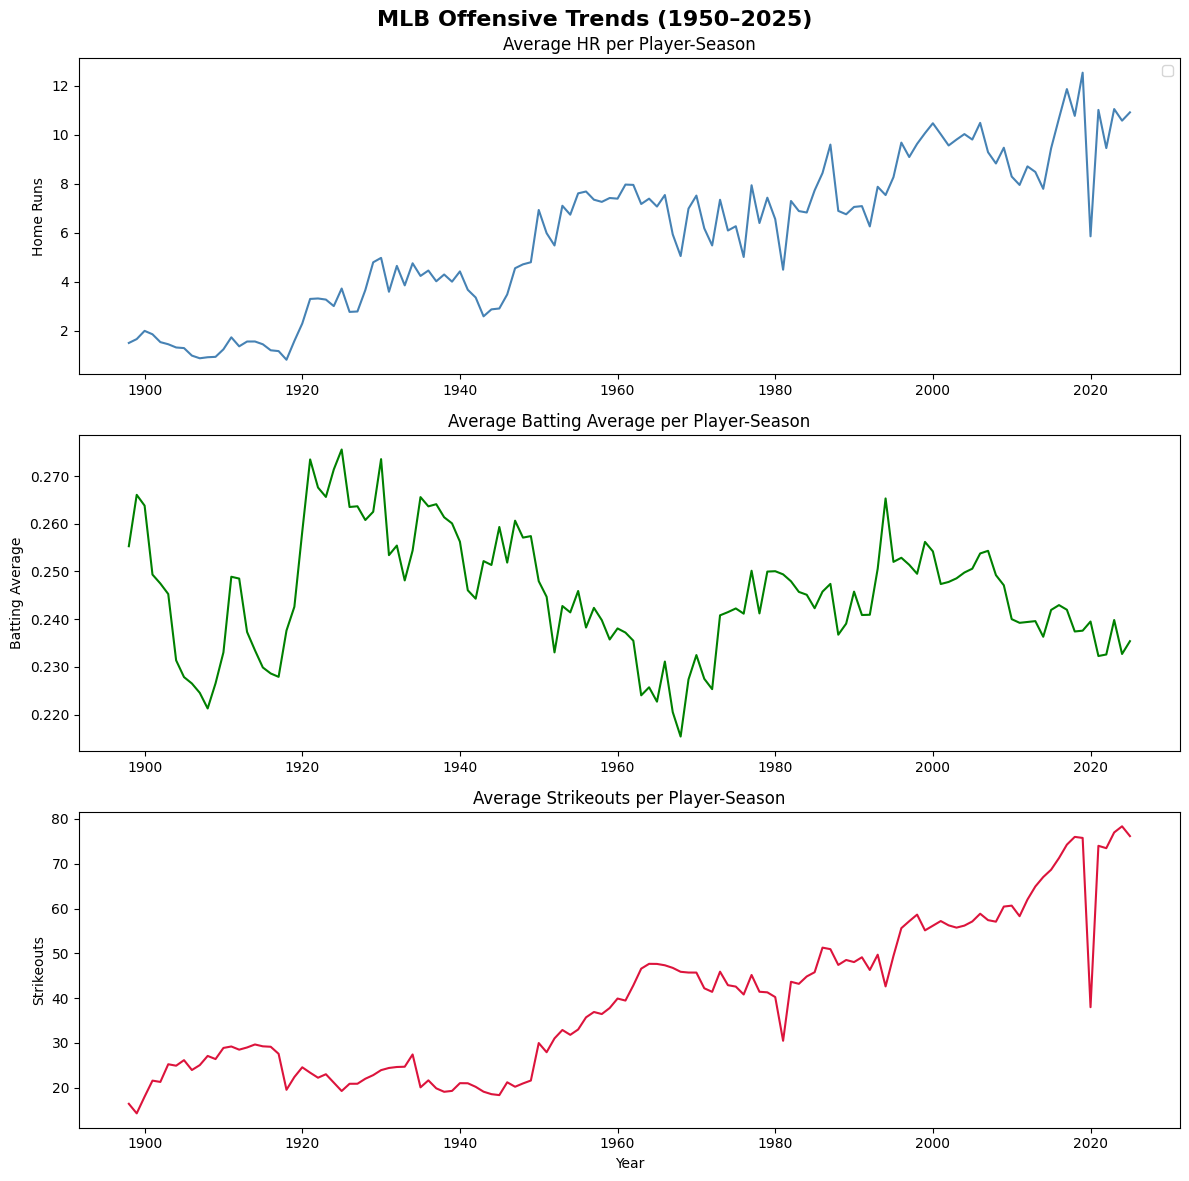

In [38]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
fig.suptitle('MLB Offensive Trends (1950–2025)', fontsize=16, fontweight='bold')

#Home runs
axes[0].plot(yearly_avg['year'], yearly_avg['avg_hr'], color='steelblue')
axes[0].set_title('Average HR per Player-Season')
axes[0].set_ylabel('Home Runs')
axes[0].legend()

#Batting average
axes[1].plot(yearly_avg['year'], yearly_avg['avg_avg'], color='green')
axes[1].set_title('Average Batting Average per Player-Season')
axes[1].set_ylabel('Batting Average')
axes[1].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

#Strikeouts
axes[2].plot(yearly_avg['year'], yearly_avg['avg_k'], color='crimson')
axes[2].set_title('Average Strikeouts per Player-Season')
axes[2].set_ylabel('Strikeouts')
axes[2].set_xlabel('Year')

plt.tight_layout()
plt.savefig('offensive_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Linear Regression Model

In [39]:
features = ['ab', 'games', 'doubles', 'triples']
target   = 'hr'

model_df = player_season[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print(f"R²  (train): {lr.score(X_train, y_train):.4f}")
print(f"R²  (test) : {r2_score(y_test, y_pred):.4f}")
print(f"RMSE (test): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print()
print("Coefficients:")
for feat, coef in zip(features, lr.coef_):
    print(f"  {feat:>10}: {coef:.4f}")
print(f"  {'intercept':>10}: {lr.intercept_:.4f}")

R²  (train): 0.4992
R²  (test) : 0.4932
RMSE (test): 6.2383

Coefficients:
          ab: 0.0086
       games: 0.0467
     doubles: 0.3258
     triples: -0.7813
   intercept: -2.2557


#### Visualization of Predicted vs. Actual Home Runs

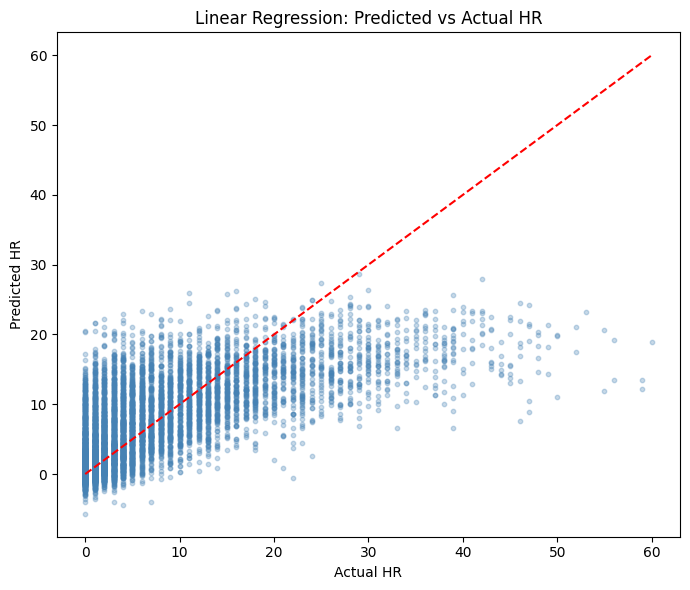

In [40]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
ax.set_xlabel('Actual HR')
ax.set_ylabel('Predicted HR')
ax.set_title('Linear Regression: Predicted vs Actual HR')
plt.tight_layout()
plt.savefig('lr_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()